# EDA - ALDIMI Predict Dataset Sintético

Notebook para realizar el **Análisis Exploratorio de Datos (EDA)** del dataset sintético ampliado de ALDIMI Predict.

Archivos analizados:

- `pacientes_riesgo_sintetico.csv`
- `consumo_inventario_diario_sintetico.csv`
- `inventario_items.csv`
- `donaciones_sinteticas.csv`
- `capturas_ia_sinteticas.csv`

El análisis cubre dimensiones, tipos de datos, nulos, duplicados, distribuciones, correlaciones, outliers, análisis de pacientes, inventario, donaciones y capturas IA/OCR.

In [1]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga del dataset

In [4]:
# ============================================================
# 2. CONFIGURACIÓN DE RUTAS Y EXTRACCIÓN
# ============================================================

ZIP_PATH = Path("ALDIMI_synthetic_dataset_v2.zip")
EXTRACT_DIR = Path("ALDIMI_synthetic_dataset_v2_ampliado")
OUTPUT_DIR = Path("outputs_eda_v2")

OUTPUT_DIR.mkdir(exist_ok=True)

if ZIP_PATH.exists() and not EXTRACT_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")
    print(f"ZIP extraído en: {EXTRACT_DIR}")
elif EXTRACT_DIR.exists():
    print(f"Carpeta encontrada: {EXTRACT_DIR}")
else:
    print("No se encontró el ZIP ni la carpeta extraída.")
    print("Sube ALDIMI_synthetic_dataset_v2_ampliado.zip y vuelve a ejecutar esta celda.")

DATA_DIR = EXTRACT_DIR / "datos"
print("DATA_DIR:", DATA_DIR)

ZIP extraído en: ALDIMI_synthetic_dataset_v2_ampliado
DATA_DIR: ALDIMI_synthetic_dataset_v2_ampliado\datos


In [5]:
# ============================================================
# 3. LECTURA DE ARCHIVOS CSV
# ============================================================

pacientes = pd.read_csv(DATA_DIR / "pacientes_riesgo_sintetico.csv")
consumo = pd.read_csv(DATA_DIR / "consumo_inventario_diario_sintetico.csv")
items = pd.read_csv(DATA_DIR / "inventario_items.csv")
donaciones = pd.read_csv(DATA_DIR / "donaciones_sinteticas.csv")
capturas_ia = pd.read_csv(DATA_DIR / "capturas_ia_sinteticas.csv")

# Conversión de fechas
pacientes["fecha_registro"] = pd.to_datetime(pacientes["fecha_registro"], errors="coerce")
consumo["fecha"] = pd.to_datetime(consumo["fecha"], errors="coerce")
donaciones["fecha"] = pd.to_datetime(donaciones["fecha"], errors="coerce")
capturas_ia["fecha_captura"] = pd.to_datetime(capturas_ia["fecha_captura"], errors="coerce")

print("Archivos cargados correctamente.")
print("Pacientes:", pacientes.shape)
print("Consumo inventario:", consumo.shape)
print("Items:", items.shape)
print("Donaciones:", donaciones.shape)
print("Capturas IA/OCR:", capturas_ia.shape)

Archivos cargados correctamente.
Pacientes: (10000, 23)
Consumo inventario: (18000, 15)
Items: (30, 8)
Donaciones: (1500, 10)
Capturas IA/OCR: (5000, 9)


## 3. Vista general de los datasets

Esta sección revisa dimensiones, duplicados, valores nulos y primeras filas.

In [6]:
datasets = {
    "pacientes": pacientes,
    "consumo": consumo,
    "items": items,
    "donaciones": donaciones,
    "capturas_ia": capturas_ia
}

resumen_general = []
for nombre, df in datasets.items():
    resumen_general.append({
        "dataset": nombre,
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "duplicados": df.duplicated().sum(),
        "valores_nulos_totales": df.isna().sum().sum()
    })

resumen_general = pd.DataFrame(resumen_general)
resumen_general.to_csv(OUTPUT_DIR / "resumen_general_datasets.csv", index=False, encoding="utf-8-sig")
resumen_general

,dataset,filas,columnas,duplicados,valores_nulos_totales
0,pacientes,10000,23,0,1410
1,consumo,18000,15,0,106
2,items,30,8,0,0
3,donaciones,1500,10,0,0
4,capturas_ia,5000,9,0,0


In [7]:
display(pacientes.head())
display(consumo.head())
display(items.head())
display(donaciones.head())
display(capturas_ia.head())

,paciente_id,fecha_registro,edad,sexo,region_origen,diagnostico_general,estado_tratamiento,dias_hospedaje,num_controles_mes,num_quimios_mes,hemoglobina_g_dl,neutrofilos,plaquetas,temperatura_c,peso_kg,imc,distancia_origen_km,ingreso_familiar_mensual,acompanante_presente,seguro_salud,alfabetizacion_digital,requiere_apoyo_psicosocial,nivel_prioridad_atencion
0,PAC00001,2025-10-06,11,F,Lima,Leucemia linfoblástica aguda,En tratamiento,51,5,0,9.300,819.000,"259,270.000",37.300,42.500,15.400,163.900,606.000,1,EsSalud,Baja,1,Medio
1,PAC00002,2025-04-04,15,F,Cusco,Linfoma,En tratamiento,32,1,2,12.200,"1,311.000","179,980.000",37.000,49.800,14.600,132.700,584.000,1,SIS,Baja,0,Bajo
2,PAC00003,2025-03-30,4,F,La Libertad,Leucemia mieloide,Recaída,127,1,3,10.600,"4,039.000","150,820.000",37.800,21.600,16.300,80.700,279.000,1,Privado,Baja,0,Medio
3,PAC00004,2025-02-18,15,F,Puno,Leucemia linfoblástica aguda,En tratamiento,32,1,2,12.800,757.000,"179,827.000",37.600,49.800,14.000,250.500,636.000,1,SIS,Baja,1,Medio
4,PAC00005,2025-09-01,9,M,Cajamarca,Tumor sólido,Inicio,89,1,1,10.600,"3,721.000","290,409.000",37.200,29.600,18.000,119.300,416.000,1,SIS,Media,0,Bajo


,fecha,item_id,nombre_item,categoria,unidad_medida,ocupacion_familias,stock_inicio,ingreso_stock,consumo_real,stock_fin,consumo_estimado_7d,consumo_estimado_14d,dias_cobertura,stock_critico_7d,stock_critico_14d
0,2025-01-01,ITM001,Arroz,alimentos,kg,51,206,0,15.400,191,99.960,199.920,13.380,0,1
1,2025-01-01,ITM002,Avena,alimentos,kg,51,108,0,6.960,101,42.840,85.680,16.500,0,0
2,2025-01-01,ITM003,Leche evaporada,alimentos,lata,51,232,0,19.270,213,124.950,249.900,11.930,0,1
3,2025-01-01,ITM004,Menestras,alimentos,kg,51,116,0,9.890,106,64.260,128.520,11.550,0,1
4,2025-01-01,ITM005,Aceite vegetal,alimentos,litro,51,73,0,3.400,70,21.420,42.840,22.880,0,0


,item_id,nombre_item,categoria,unidad_medida,consumo_base_por_familia,stock_seguridad_7d,stock_maximo_referencial,es_critico
0,ITM001,Arroz,alimentos,kg,0.280,12,240,0
1,ITM002,Avena,alimentos,kg,0.120,8,140,0
2,ITM003,Leche evaporada,alimentos,lata,0.350,18,360,0
3,ITM004,Menestras,alimentos,kg,0.180,10,180,0
4,ITM005,Aceite vegetal,alimentos,litro,0.060,4,90,0


,donacion_id,fecha,tipo_donante,item_id,nombre_item,categoria,unidad_medida,cantidad_donada,valor_estimado_soles,campania
0,DON00001,2026-07-10,Persona natural,ITM010,Frutas,alimentos,kg,28,401.550,Aniversario ALDIMI
1,DON00002,2025-06-11,Persona natural,ITM007,Conservas de atún,alimentos,lata,62,370.260,Regular
2,DON00003,2026-04-30,Empresa,ITM030,Paracetamol pediátrico,medicamentos_soporte,frasco,62,"1,093.250",Regular
3,DON00004,2025-09-11,Empresa,ITM013,Papel higiénico,higiene,rollo,11,75.090,Aniversario ALDIMI
4,DON00005,2025-02-06,Universidad,ITM011,Agua embotellada,alimentos,litro,27,72.310,Regular


,captura_id,fecha_captura,paciente_id,tipo_documento,calidad_imagen,confianza_ocr,campos_extraidos,requiere_revision_manual,origen_captura
0,OCR00001,2026-02-04,PAC07552,Receta médica,Alta,0.892,medicamento|dosis|fecha|frecuencia,0,Web
1,OCR00002,2025-03-20,PAC00900,Informe social,Alta,0.944,acompanante|region_origen|ingreso_familiar|nec...,0,Web
2,OCR00003,2025-03-09,PAC05296,Informe social,Alta,0.970,acompanante|necesidad_social|ingreso_familiar,0,Web
3,OCR00004,2025-07-26,PAC09064,Orden de laboratorio,Alta,0.911,plaquetas|neutrofilos|fecha,0,Móvil
4,OCR00005,2025-07-07,PAC03328,Receta médica,Alta,0.946,medicamento|fecha|dosis,0,Web


In [8]:
for nombre, df in datasets.items():
    print("="*80)
    print(nombre.upper())
    print("="*80)
    display(pd.DataFrame({
        "columna": df.columns,
        "tipo": df.dtypes.astype(str).values,
        "nulos": df.isna().sum().values,
        "nulos_%": (df.isna().mean().values * 100).round(2)
    }))

PACIENTES


,columna,tipo,nulos,nulos_%
0,paciente_id,object,0,0.000
1,fecha_registro,datetime64[ns],0,0.000
2,edad,int64,0,0.000
3,sexo,object,0,0.000
4,region_origen,object,0,0.000
5,diagnostico_general,object,0,0.000
6,estado_tratamiento,object,0,0.000
7,dias_hospedaje,int64,0,0.000
8,num_controles_mes,int64,0,0.000
9,num_quimios_mes,int64,0,0.000


CONSUMO


,columna,tipo,nulos,nulos_%
0,fecha,datetime64[ns],0,0.000
1,item_id,object,0,0.000
2,nombre_item,object,0,0.000
3,categoria,object,0,0.000
4,unidad_medida,object,0,0.000
5,ocupacion_familias,int64,0,0.000
6,stock_inicio,int64,0,0.000
7,ingreso_stock,int64,0,0.000
8,consumo_real,float64,106,0.590
9,stock_fin,int64,0,0.000


ITEMS


,columna,tipo,nulos,nulos_%
0,item_id,object,0,0.000
1,nombre_item,object,0,0.000
2,categoria,object,0,0.000
3,unidad_medida,object,0,0.000
4,consumo_base_por_familia,float64,0,0.000
5,stock_seguridad_7d,int64,0,0.000
6,stock_maximo_referencial,int64,0,0.000
7,es_critico,int64,0,0.000


DONACIONES


,columna,tipo,nulos,nulos_%
0,donacion_id,object,0,0.000
1,fecha,datetime64[ns],0,0.000
2,tipo_donante,object,0,0.000
3,item_id,object,0,0.000
4,nombre_item,object,0,0.000
5,categoria,object,0,0.000
6,unidad_medida,object,0,0.000
7,cantidad_donada,int64,0,0.000
8,valor_estimado_soles,float64,0,0.000
9,campania,object,0,0.000


CAPTURAS_IA


,columna,tipo,nulos,nulos_%
0,captura_id,object,0,0.000
1,fecha_captura,datetime64[ns],0,0.000
2,paciente_id,object,0,0.000
3,tipo_documento,object,0,0.000
4,calidad_imagen,object,0,0.000
5,confianza_ocr,float64,0,0.000
6,campos_extraidos,object,0,0.000
7,requiere_revision_manual,int64,0,0.000
8,origen_captura,object,0,0.000


## 4. Análisis de valores nulos

Permite justificar la fase de limpieza y preparación de datos.

In [9]:
def resumen_nulos(df, nombre_dataset):
    tabla = pd.DataFrame({
        "dataset": nombre_dataset,
        "columna": df.columns,
        "nulos": df.isna().sum().values,
        "porcentaje_nulos": (df.isna().mean().values * 100).round(2)
    })
    return tabla.sort_values("porcentaje_nulos", ascending=False)

nulos_total = pd.concat(
    [resumen_nulos(df, nombre) for nombre, df in datasets.items()],
    ignore_index=True
)

nulos_total.to_csv(OUTPUT_DIR / "resumen_nulos.csv", index=False, encoding="utf-8-sig")
nulos_total[nulos_total["nulos"] > 0]

,dataset,columna,nulos,porcentaje_nulos
0,pacientes,ingreso_familiar_mensual,405,4.050
1,pacientes,hemoglobina_g_dl,240,2.400
2,pacientes,imc,206,2.060
3,pacientes,plaquetas,206,2.060
4,pacientes,neutrofilos,194,1.940
5,pacientes,alfabetizacion_digital,159,1.590
23,consumo,consumo_real,106,0.590


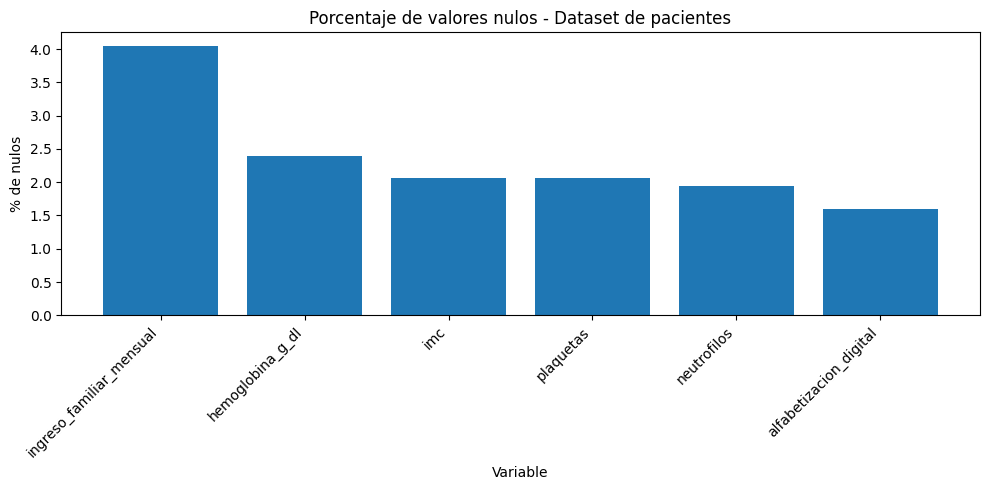

In [10]:
nulos_pac = resumen_nulos(pacientes, "pacientes")
nulos_pac = nulos_pac[nulos_pac["nulos"] > 0]

plt.figure(figsize=(10, 5))
plt.bar(nulos_pac["columna"], nulos_pac["porcentaje_nulos"])
plt.title("Porcentaje de valores nulos - Dataset de pacientes")
plt.xlabel("Variable")
plt.ylabel("% de nulos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nulos_pacientes.png", dpi=150)
plt.show()

## 5. EDA del dataset de pacientes

Este dataset se usa para el modelo de clasificación supervisada del `nivel_prioridad_atencion`.

In [11]:
display(pacientes.describe(include="all").T)

pacientes.describe(include="all").T.to_csv(
    OUTPUT_DIR / "estadisticas_descriptivas_pacientes.csv",
    encoding="utf-8-sig"
)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
paciente_id,10000,10000,PAC09984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_registro,10000,NaN,NaN,NaN,2025-10-09 02:06:25.920000,2025-01-01 00:00:00,2025-05-22 00:00:00,2025-10-11 00:00:00,2026-02-26 06:00:00,2026-07-11 00:00:00,NaN
edad,"10,000.000",NaN,NaN,NaN,9.191,1.000,6.000,9.000,12.000,17.000,4.013
sexo,10000,2,M,5081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region_origen,10000,12,Huánuco,887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diagnostico_general,10000,6,Leucemia linfoblástica aguda,4133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estado_tratamiento,10000,4,En tratamiento,4840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dias_hospedaje,"10,000.000",NaN,NaN,NaN,58.547,2.000,34.000,52.000,76.000,413.000,34.540
num_controles_mes,"10,000.000",NaN,NaN,NaN,2.609,0.000,1.000,2.000,4.000,12.000,1.614
num_quimios_mes,"10,000.000",NaN,NaN,NaN,1.411,0.000,1.000,1.000,2.000,8.000,1.197


In [12]:
dist_prioridad = pacientes["nivel_prioridad_atencion"].value_counts().reset_index()
dist_prioridad.columns = ["nivel_prioridad_atencion", "cantidad"]
dist_prioridad["porcentaje"] = (dist_prioridad["cantidad"] / len(pacientes) * 100).round(2)

dist_prioridad.to_csv(OUTPUT_DIR / "distribucion_prioridad_pacientes.csv", index=False, encoding="utf-8-sig")
dist_prioridad

,nivel_prioridad_atencion,cantidad,porcentaje
0,Bajo,6232,62.320
1,Medio,3235,32.350
2,Alto,533,5.330


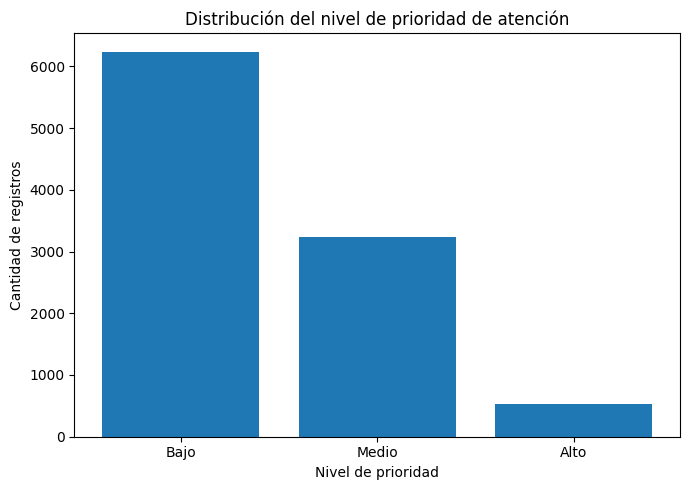

In [13]:
plt.figure(figsize=(7, 5))
plt.bar(dist_prioridad["nivel_prioridad_atencion"], dist_prioridad["cantidad"])
plt.title("Distribución del nivel de prioridad de atención")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribucion_prioridad_atencion.png", dpi=150)
plt.show()

In [14]:
estado_tabla = pd.crosstab(
    pacientes["estado_tratamiento"],
    pacientes["nivel_prioridad_atencion"],
    normalize="index"
).round(3) * 100

estado_tabla.to_csv(OUTPUT_DIR / "prioridad_por_estado_tratamiento.csv", encoding="utf-8-sig")
estado_tabla

nivel_prioridad_atencion,Alto,Bajo,Medio
estado_tratamiento,,,
En tratamiento,3.400,68.900,27.600
Inicio,8.400,52.100,39.500
Recaída,11.700,39.300,49.000
Seguimiento,3.700,67.700,28.700


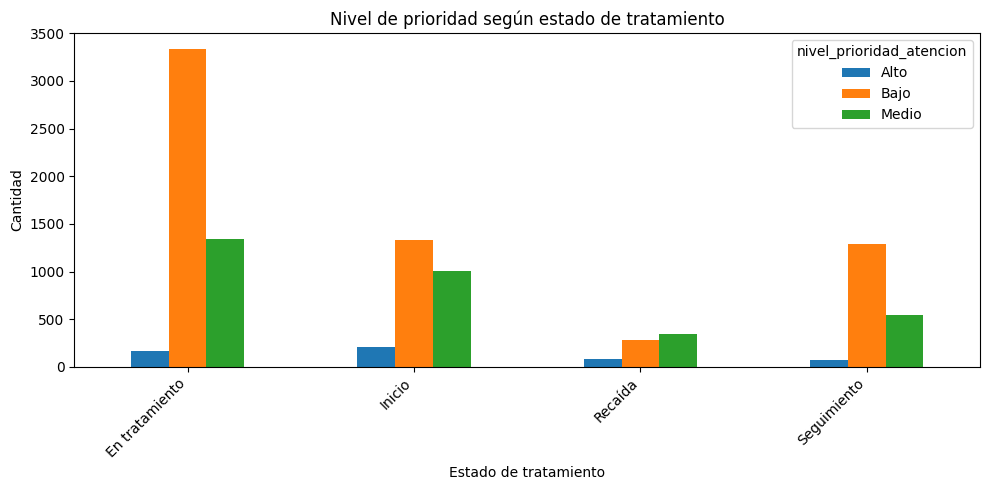

In [15]:
estado_counts = pd.crosstab(pacientes["estado_tratamiento"], pacientes["nivel_prioridad_atencion"])

estado_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Nivel de prioridad según estado de tratamiento")
plt.xlabel("Estado de tratamiento")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "prioridad_por_estado_tratamiento.png", dpi=150)
plt.show()

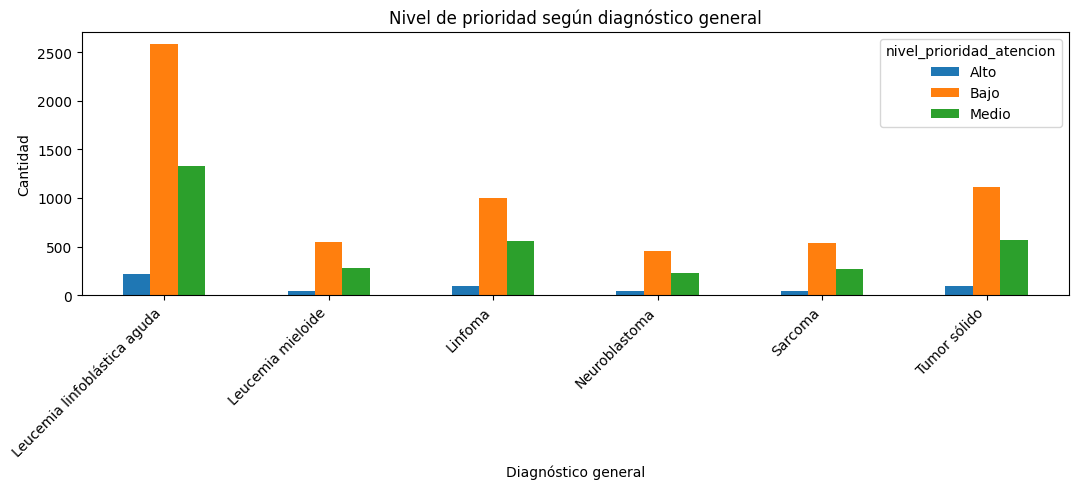

In [16]:
diag_counts = pd.crosstab(pacientes["diagnostico_general"], pacientes["nivel_prioridad_atencion"])

diag_counts.plot(kind="bar", figsize=(11, 5))
plt.title("Nivel de prioridad según diagnóstico general")
plt.xlabel("Diagnóstico general")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "prioridad_por_diagnostico.png", dpi=150)
plt.show()

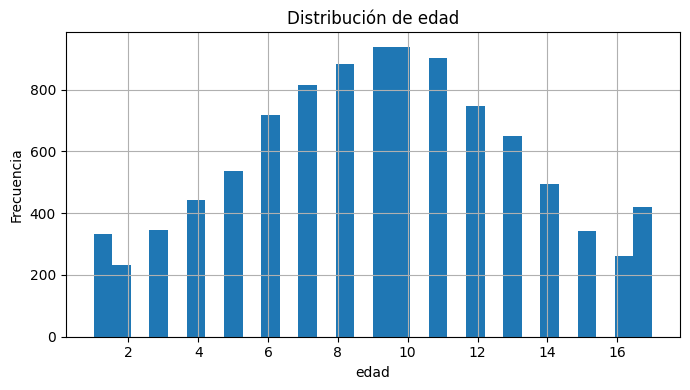

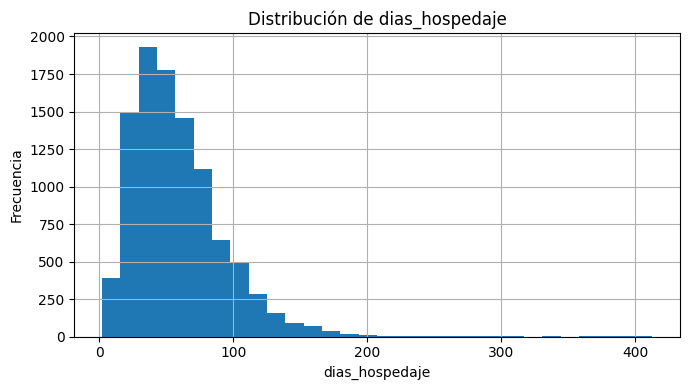

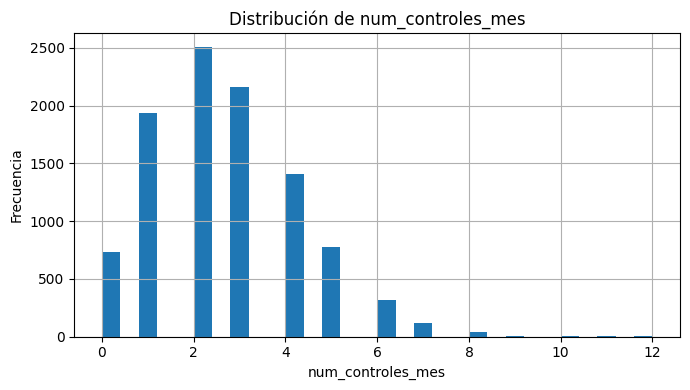

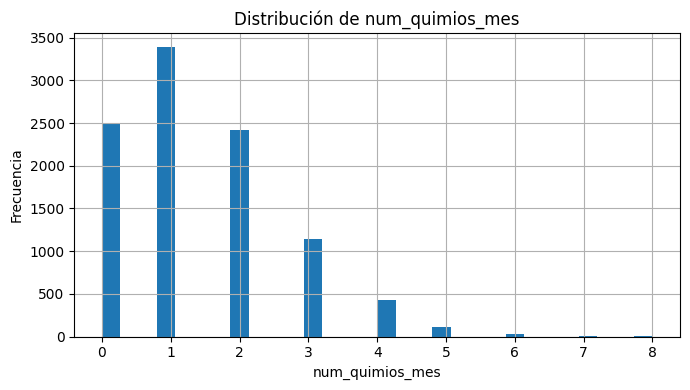

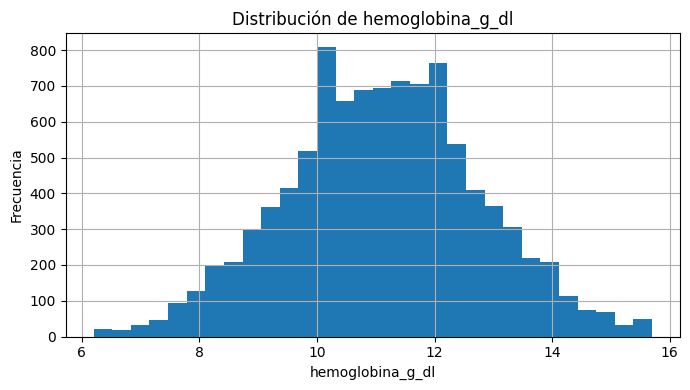

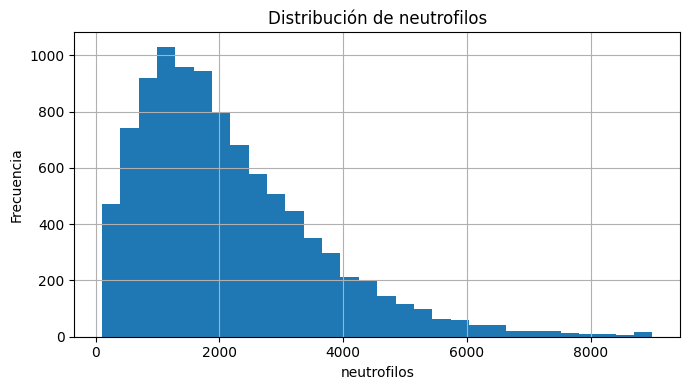

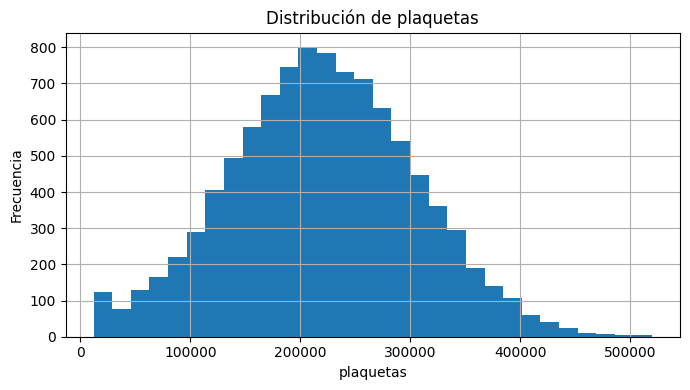

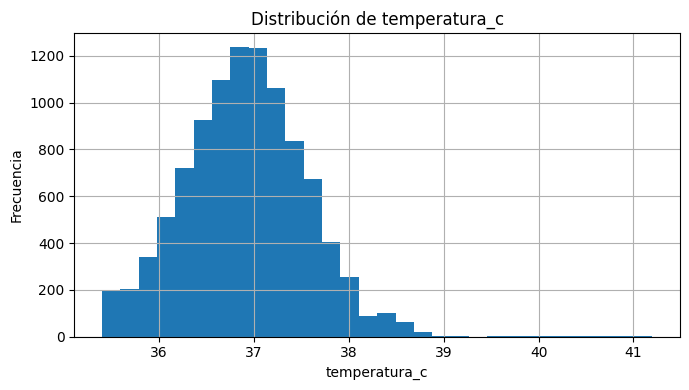

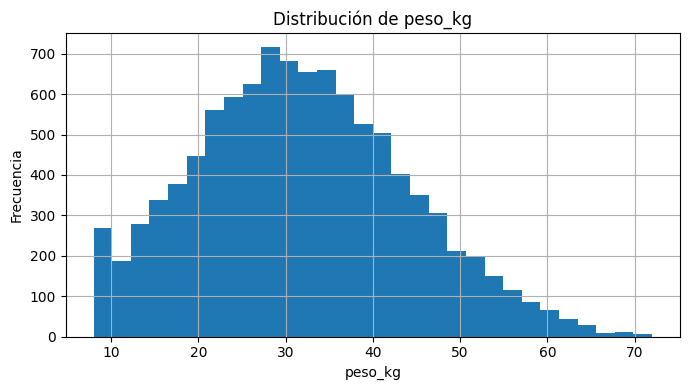

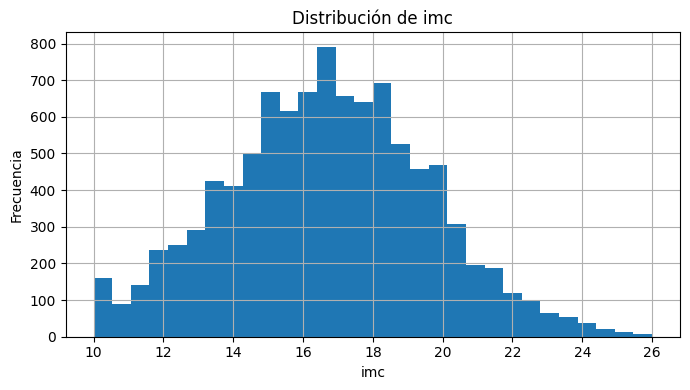

In [17]:
variables_clinicas = [
    "edad", "dias_hospedaje", "num_controles_mes", "num_quimios_mes",
    "hemoglobina_g_dl", "neutrofilos", "plaquetas", "temperatura_c",
    "peso_kg", "imc"
]

for col in variables_clinicas:
    plt.figure(figsize=(7, 4))
    pacientes[col].dropna().hist(bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"hist_{col}.png", dpi=150)
    plt.show()

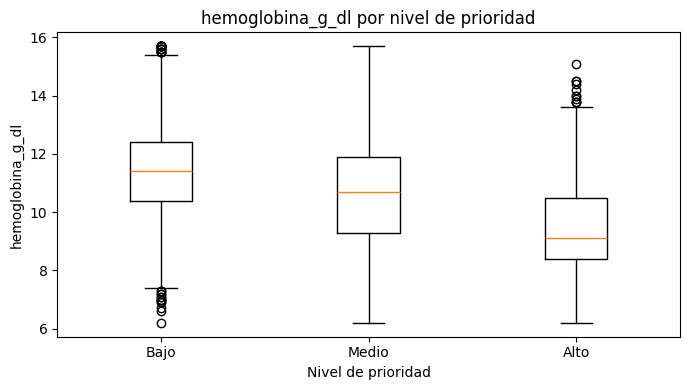

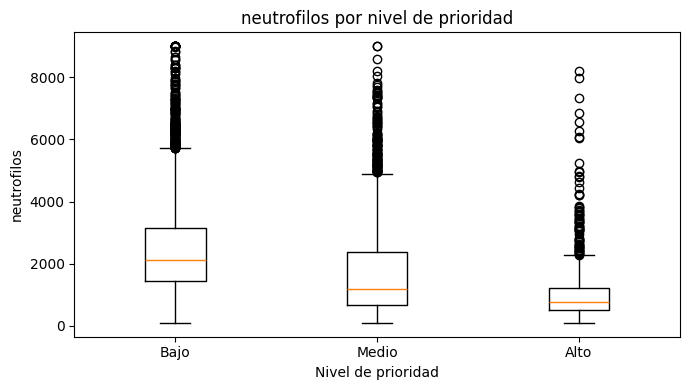

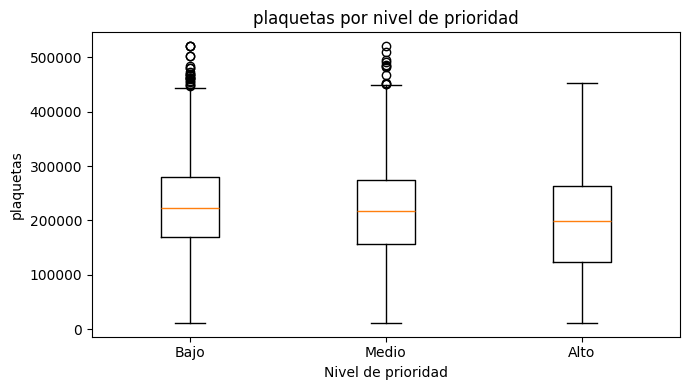

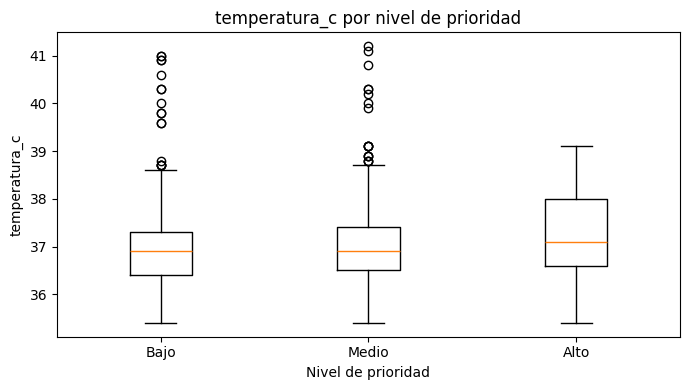

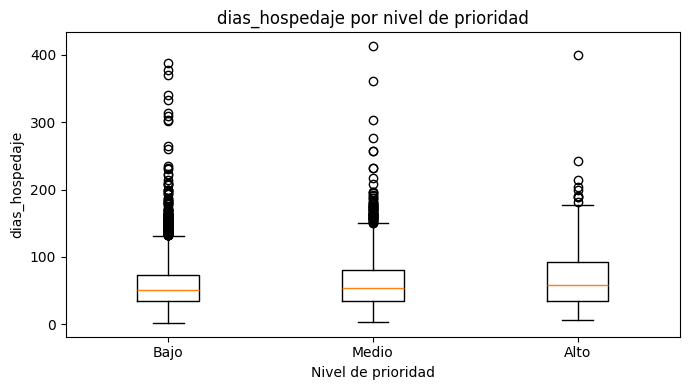

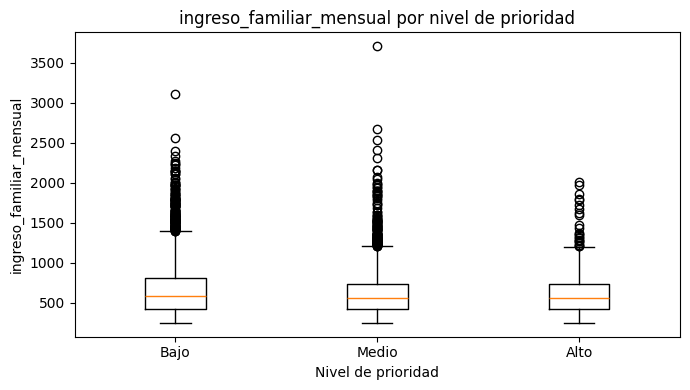

In [18]:
for col in ["hemoglobina_g_dl", "neutrofilos", "plaquetas", "temperatura_c", "dias_hospedaje", "ingreso_familiar_mensual"]:
    data = [
        pacientes.loc[pacientes["nivel_prioridad_atencion"] == nivel, col].dropna()
        for nivel in ["Bajo", "Medio", "Alto"]
    ]
    plt.figure(figsize=(7, 4))
    plt.boxplot(data, labels=["Bajo", "Medio", "Alto"])
    plt.title(f"{col} por nivel de prioridad")
    plt.xlabel("Nivel de prioridad")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"boxplot_{col}_por_prioridad.png", dpi=150)
    plt.show()

## 6. Correlaciones en pacientes

In [19]:
numeric_pacientes = pacientes.select_dtypes(include=["number"])
corr_pacientes = numeric_pacientes.corr()

corr_pacientes.to_csv(OUTPUT_DIR / "correlacion_pacientes.csv", encoding="utf-8-sig")
corr_pacientes

,edad,dias_hospedaje,num_controles_mes,num_quimios_mes,hemoglobina_g_dl,neutrofilos,plaquetas,temperatura_c,peso_kg,imc,distancia_origen_km,ingreso_familiar_mensual,acompanante_presente,requiere_apoyo_psicosocial
edad,1.000,-0.003,-0.010,-0.004,-0.000,-0.023,0.012,-0.002,0.896,-0.008,0.013,0.009,0.003,-0.000
dias_hospedaje,-0.003,1.000,0.006,-0.009,-0.000,0.005,-0.010,0.024,0.001,0.002,-0.006,0.004,-0.007,0.005
num_controles_mes,-0.010,0.006,1.000,-0.013,-0.002,-0.010,-0.020,0.009,-0.005,0.006,0.001,-0.006,0.005,0.012
num_quimios_mes,-0.004,-0.009,-0.013,1.000,0.004,-0.016,0.001,-0.006,-0.003,-0.009,-0.001,-0.006,0.003,0.001
hemoglobina_g_dl,-0.000,-0.000,-0.002,0.004,1.000,0.001,0.017,-0.002,-0.004,0.073,0.007,0.013,-0.003,-0.002
neutrofilos,-0.023,0.005,-0.010,-0.016,0.001,1.000,-0.007,0.008,-0.021,0.002,-0.015,-0.007,0.017,0.003
plaquetas,0.012,-0.010,-0.020,0.001,0.017,-0.007,1.000,0.007,0.010,-0.001,0.017,-0.004,0.006,0.010
temperatura_c,-0.002,0.024,0.009,-0.006,-0.002,0.008,0.007,1.000,0.005,0.009,-0.007,0.000,-0.006,0.002
peso_kg,0.896,0.001,-0.005,-0.003,-0.004,-0.021,0.010,0.005,1.000,-0.005,0.011,0.012,0.000,-0.001
imc,-0.008,0.002,0.006,-0.009,0.073,0.002,-0.001,0.009,-0.005,1.000,0.012,0.002,0.010,0.008


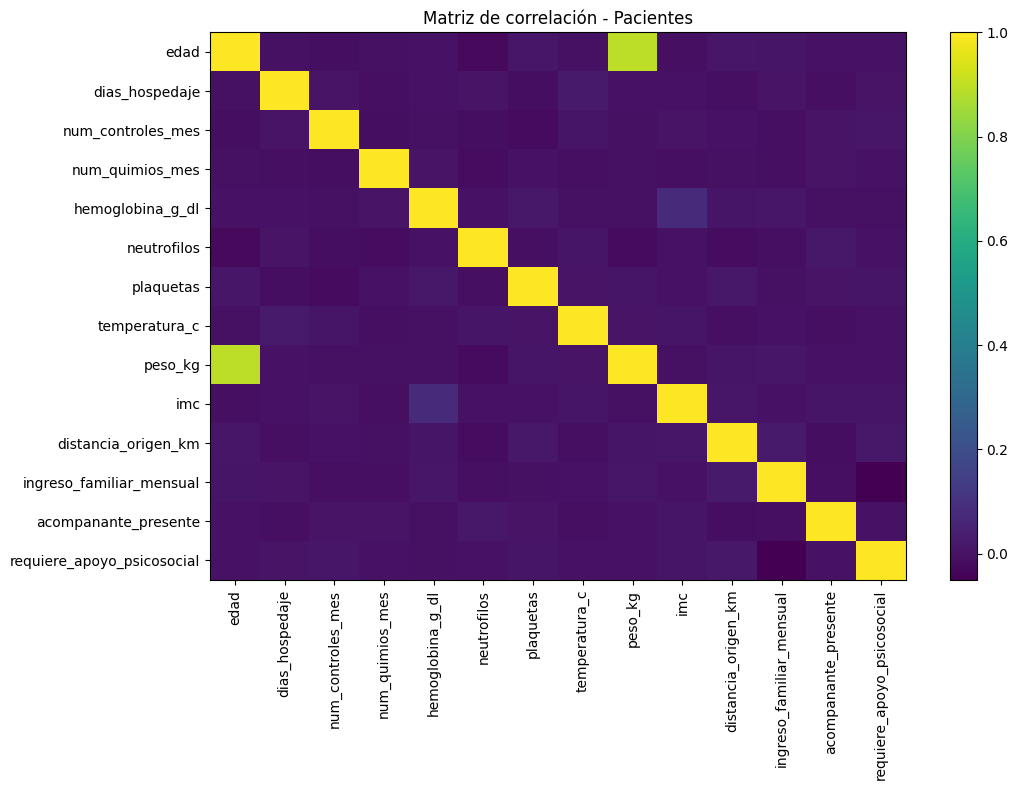

In [20]:
plt.figure(figsize=(11, 8))
plt.imshow(corr_pacientes, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_pacientes.columns)), corr_pacientes.columns, rotation=90)
plt.yticks(range(len(corr_pacientes.columns)), corr_pacientes.columns)
plt.title("Matriz de correlación - Pacientes")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matriz_correlacion_pacientes.png", dpi=150)
plt.show()

## 7. Detección inicial de outliers

Se usa el método IQR. No todos los outliers deben eliminarse; primero deben evaluarse según el contexto.

In [21]:
def detectar_outliers_iqr(df, columnas):
    resultados = []
    for col in columnas:
        serie = df[col].dropna()
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        limite_inf = q1 - 1.5 * iqr
        limite_sup = q3 + 1.5 * iqr
        n_outliers = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
        resultados.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": limite_inf,
            "limite_superior": limite_sup,
            "cantidad_outliers": n_outliers,
            "porcentaje_outliers": round(n_outliers / len(df) * 100, 2)
        })
    return pd.DataFrame(resultados)

outliers_pacientes = detectar_outliers_iqr(
    pacientes,
    ["edad", "dias_hospedaje", "hemoglobina_g_dl", "neutrofilos", "plaquetas",
     "temperatura_c", "peso_kg", "imc", "distancia_origen_km", "ingreso_familiar_mensual"]
)

outliers_pacientes.to_csv(OUTPUT_DIR / "outliers_pacientes_iqr.csv", index=False, encoding="utf-8-sig")
outliers_pacientes.sort_values("porcentaje_outliers", ascending=False)

,variable,q1,q3,iqr,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
9,ingreso_familiar_mensual,425.000,783.000,358.000,-112.000,"1,320.000",307,3.070
8,distancia_origen_km,151.000,385.500,234.500,-200.750,737.250,298,2.980
3,neutrofilos,"1,076.250","2,900.750","1,824.500","-1,660.500","5,637.500",281,2.810
1,dias_hospedaje,34.000,76.000,42.000,-29.000,139.000,249,2.490
5,temperatura_c,36.500,37.300,0.800,35.300,38.500,111,1.110
2,hemoglobina_g_dl,10.000,12.200,2.200,6.700,15.500,76,0.760
4,plaquetas,"163,162.500","277,428.750","114,266.250","-8,236.875","448,828.125",34,0.340
6,peso_kg,23.100,39.900,16.800,-2.100,65.100,32,0.320
7,imc,14.700,18.700,4.000,8.700,24.700,27,0.270
0,edad,6.000,12.000,6.000,-3.000,21.000,0,0.000


## 8. EDA de inventario y consumo

Este dataset se usa para predicción de demanda y alertas de stock crítico a 7 y 14 días.

In [22]:
display(consumo.describe(include="all").T)

consumo.describe(include="all").T.to_csv(
    OUTPUT_DIR / "estadisticas_descriptivas_consumo.csv",
    encoding="utf-8-sig"
)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
fecha,18000,NaN,NaN,NaN,2025-10-27 12:00:00,2025-01-01 00:00:00,2025-05-30 18:00:00,2025-10-27 12:00:00,2026-03-26 06:00:00,2026-08-23 00:00:00,NaN
item_id,18000,30,ITM001,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_item,18000,30,Arroz,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categoria,18000,4,alimentos,7200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unidad_medida,18000,9,unidad,5400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ocupacion_familias,"18,000.000",NaN,NaN,NaN,75.405,41.000,62.750,76.000,88.000,109.000,15.438
stock_inicio,"18,000.000",NaN,NaN,NaN,77.280,0.000,22.000,47.000,91.250,847.000,93.744
ingreso_stock,"18,000.000",NaN,NaN,NaN,17.024,0.000,0.000,0.000,0.000,778.000,60.405
consumo_real,"17,894.000",NaN,NaN,NaN,17.470,0.000,6.230,11.920,22.450,294.410,16.850
stock_fin,"18,000.000",NaN,NaN,NaN,77.028,0.000,22.000,47.000,91.000,819.000,93.230


In [23]:
stock_critico_resumen = pd.DataFrame({
    "target": ["stock_critico_7d", "stock_critico_14d"],
    "cantidad_alertas": [
        consumo["stock_critico_7d"].sum(),
        consumo["stock_critico_14d"].sum()
    ],
    "porcentaje_alertas": [
        round(consumo["stock_critico_7d"].mean() * 100, 2),
        round(consumo["stock_critico_14d"].mean() * 100, 2)
    ]
})

stock_critico_resumen.to_csv(OUTPUT_DIR / "resumen_stock_critico.csv", index=False, encoding="utf-8-sig")
stock_critico_resumen

,target,cantidad_alertas,porcentaje_alertas
0,stock_critico_7d,12831,71.280
1,stock_critico_14d,16971,94.280


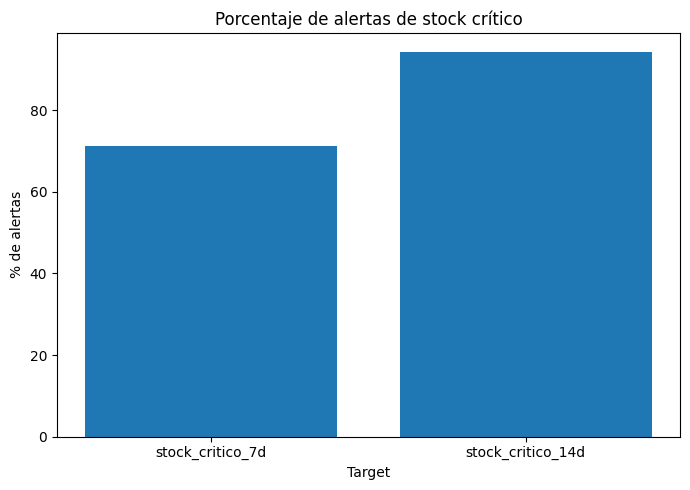

In [24]:
plt.figure(figsize=(7, 5))
plt.bar(stock_critico_resumen["target"], stock_critico_resumen["porcentaje_alertas"])
plt.title("Porcentaje de alertas de stock crítico")
plt.xlabel("Target")
plt.ylabel("% de alertas")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "porcentaje_alertas_stock_critico.png", dpi=150)
plt.show()

In [25]:
consumo_categoria = consumo.groupby("categoria").agg(
    consumo_promedio=("consumo_real", "mean"),
    consumo_total=("consumo_real", "sum"),
    stock_promedio=("stock_fin", "mean"),
    dias_cobertura_promedio=("dias_cobertura", "mean"),
    alerta_7d_rate=("stock_critico_7d", "mean"),
    alerta_14d_rate=("stock_critico_14d", "mean")
).reset_index()

consumo_categoria["alerta_7d_rate"] = (consumo_categoria["alerta_7d_rate"] * 100).round(2)
consumo_categoria["alerta_14d_rate"] = (consumo_categoria["alerta_14d_rate"] * 100).round(2)

consumo_categoria.to_csv(OUTPUT_DIR / "consumo_por_categoria.csv", index=False, encoding="utf-8-sig")
consumo_categoria

,categoria,consumo_promedio,consumo_total,stock_promedio,dias_cobertura_promedio,alerta_7d_rate,alerta_14d_rate
0,alimentos,15.895,"113,837.960",60.402,4.428,80.280,97.580
1,higiene,18.238,"65,236.740",68.101,5.333,73.030,95.000
2,insumos_medicos,20.008,"119,269.990",103.622,6.760,61.370,90.270
3,medicamentos_soporte,11.943,"14,259.710",70.596,6.532,61.670,92.420


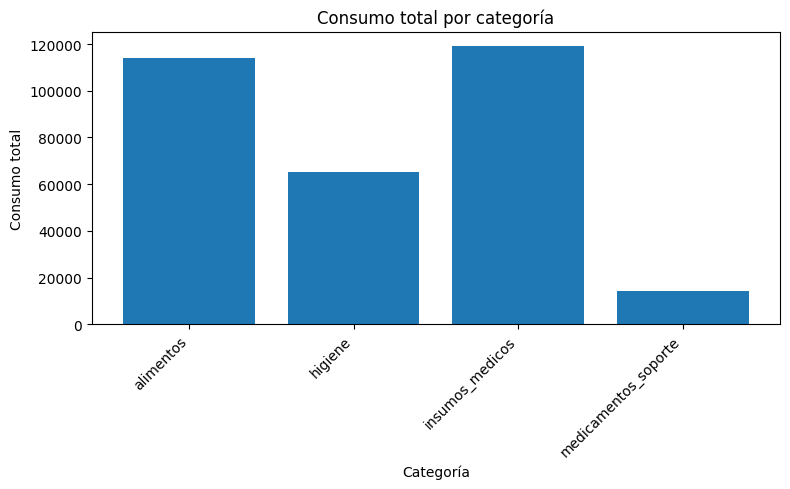

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(consumo_categoria["categoria"], consumo_categoria["consumo_total"])
plt.title("Consumo total por categoría")
plt.xlabel("Categoría")
plt.ylabel("Consumo total")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "consumo_total_por_categoria.png", dpi=150)
plt.show()

In [27]:
top_consumo_items = consumo.groupby(["item_id", "nombre_item", "categoria"]).agg(
    consumo_total=("consumo_real", "sum"),
    consumo_promedio=("consumo_real", "mean"),
    alertas_7d=("stock_critico_7d", "sum"),
    alertas_14d=("stock_critico_14d", "sum")
).reset_index().sort_values("consumo_total", ascending=False).head(10)

top_consumo_items.to_csv(OUTPUT_DIR / "top_10_items_consumo.csv", index=False, encoding="utf-8-sig")
top_consumo_items

,item_id,nombre_item,categoria,consumo_total,consumo_promedio,alertas_7d,alertas_14d
18,ITM019,Mascarillas,insumos_medicos,"38,020.600",63.793,452,580
19,ITM020,Guantes descartables,insumos_medicos,"30,663.140",51.708,426,567
14,ITM015,Pañales,higiene,"24,880.950",41.607,584,600
10,ITM011,Agua embotellada,alimentos,"22,683.040",37.995,436,584
12,ITM013,Papel higiénico,higiene,"20,616.650",34.534,515,595
22,ITM023,Baja lenguas,insumos_medicos,"16,529.880",27.596,376,544
2,ITM003,Leche evaporada,alimentos,"16,207.630",27.240,543,600
0,ITM001,Arroz,alimentos,"13,009.830",21.829,576,600
26,ITM027,Jeringas descartables,insumos_medicos,"11,821.690",20.003,380,551
7,ITM008,Galletas nutritivas,alimentos,"10,923.460",18.297,511,595


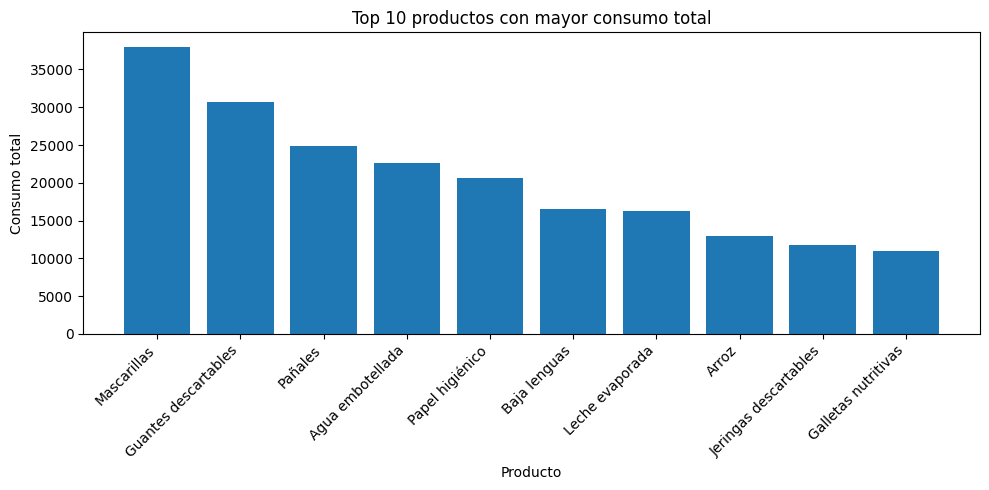

In [28]:
plt.figure(figsize=(10, 5))
plt.bar(top_consumo_items["nombre_item"], top_consumo_items["consumo_total"])
plt.title("Top 10 productos con mayor consumo total")
plt.xlabel("Producto")
plt.ylabel("Consumo total")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_10_productos_consumo.png", dpi=150)
plt.show()

In [29]:
consumo_diario = consumo.groupby("fecha").agg(
    ocupacion_familias=("ocupacion_familias", "mean"),
    consumo_total_diario=("consumo_real", "sum"),
    stock_total_fin=("stock_fin", "sum"),
    alertas_7d=("stock_critico_7d", "sum"),
    alertas_14d=("stock_critico_14d", "sum")
).reset_index()

consumo_diario.to_csv(OUTPUT_DIR / "consumo_diario_agregado.csv", index=False, encoding="utf-8-sig")
consumo_diario.head()

,fecha,ocupacion_familias,consumo_total_diario,stock_total_fin,alertas_7d,alertas_14d
0,2025-01-01,51.000,321.350,6540,0,5
1,2025-01-02,59.000,400.550,6195,1,9
2,2025-01-03,58.000,388.370,5836,1,12
3,2025-01-04,56.000,361.530,5525,1,10
4,2025-01-05,55.000,373.440,5284,1,11


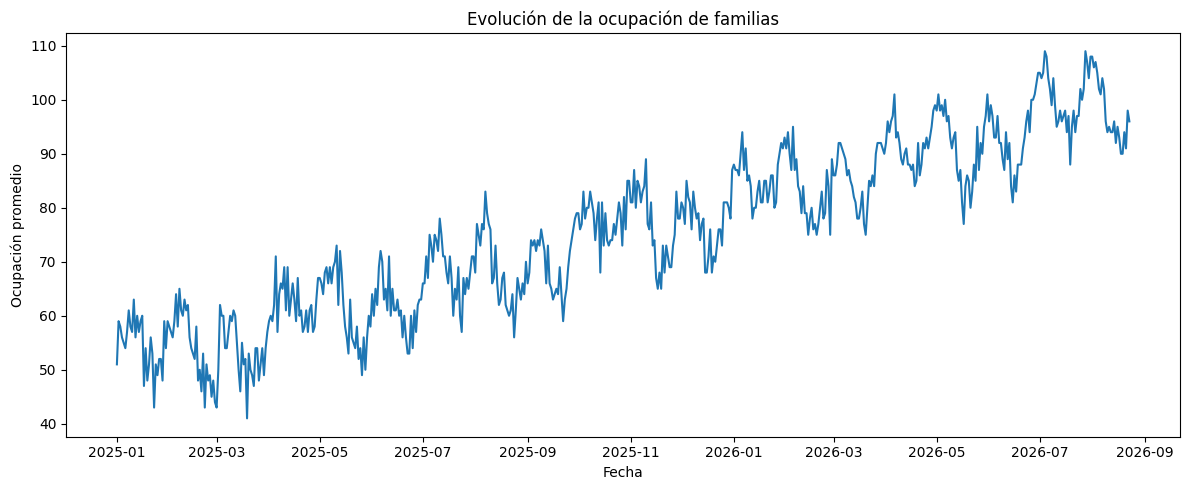

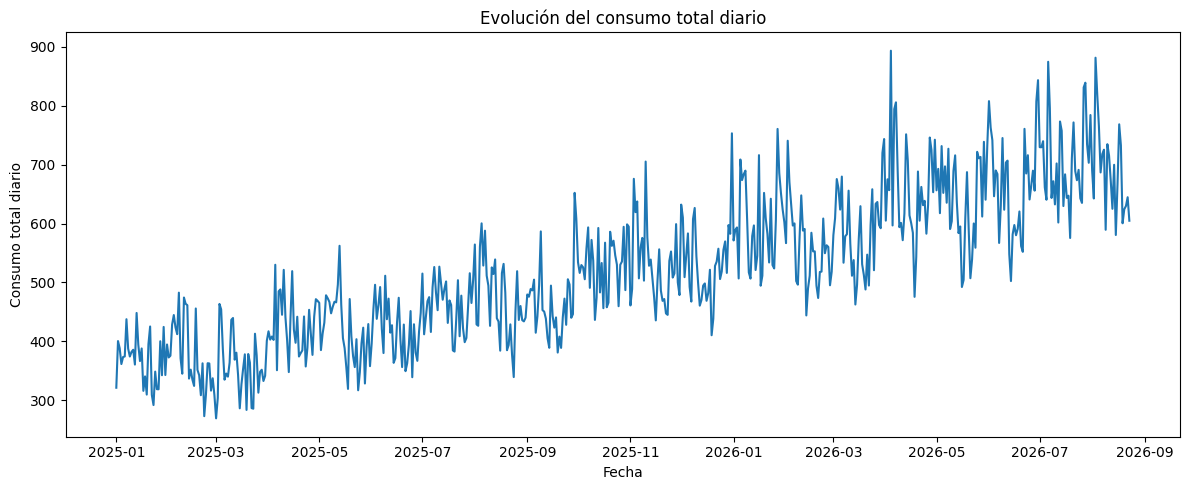

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(consumo_diario["fecha"], consumo_diario["ocupacion_familias"])
plt.title("Evolución de la ocupación de familias")
plt.xlabel("Fecha")
plt.ylabel("Ocupación promedio")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "evolucion_ocupacion_familias.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(consumo_diario["fecha"], consumo_diario["consumo_total_diario"])
plt.title("Evolución del consumo total diario")
plt.xlabel("Fecha")
plt.ylabel("Consumo total diario")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "evolucion_consumo_total_diario.png", dpi=150)
plt.show()

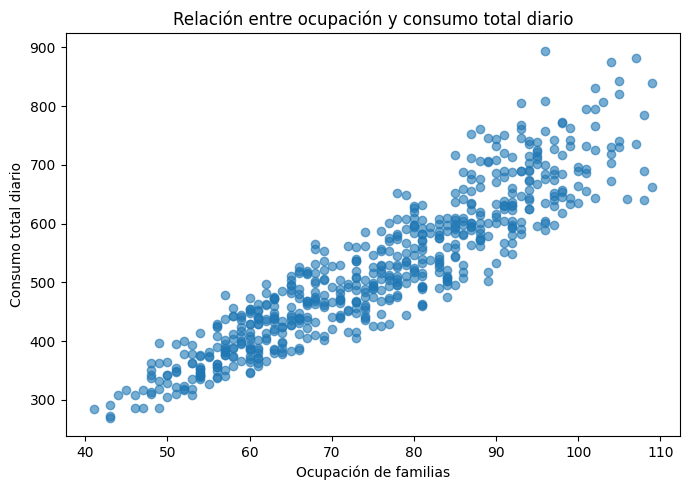

,ocupacion_familias,consumo_total_diario
ocupacion_familias,1.000,0.917
consumo_total_diario,0.917,1.000


In [31]:
plt.figure(figsize=(7, 5))
plt.scatter(consumo_diario["ocupacion_familias"], consumo_diario["consumo_total_diario"], alpha=0.6)
plt.title("Relación entre ocupación y consumo total diario")
plt.xlabel("Ocupación de familias")
plt.ylabel("Consumo total diario")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "scatter_ocupacion_vs_consumo.png", dpi=150)
plt.show()

consumo_diario[["ocupacion_familias", "consumo_total_diario"]].corr()

## 9. Correlaciones en inventario

In [32]:
numeric_consumo = consumo.select_dtypes(include=["number"])
corr_consumo = numeric_consumo.corr()

corr_consumo.to_csv(OUTPUT_DIR / "correlacion_consumo.csv", encoding="utf-8-sig")
corr_consumo

,ocupacion_familias,stock_inicio,ingreso_stock,consumo_real,stock_fin,consumo_estimado_7d,consumo_estimado_14d,dias_cobertura,stock_critico_7d,stock_critico_14d
ocupacion_familias,1.000,-0.063,0.067,0.229,-0.061,0.240,0.240,-0.353,0.293,0.235
stock_inicio,-0.063,1.000,-0.158,0.551,0.804,0.581,0.581,0.218,-0.184,-0.087
ingreso_stock,0.067,-0.158,1.000,0.242,0.446,0.259,0.259,0.142,-0.137,-0.056
consumo_real,0.229,0.551,0.242,1.000,0.540,0.945,0.945,-0.252,0.210,0.140
stock_fin,-0.061,0.804,0.446,0.540,1.000,0.583,0.583,0.356,-0.311,-0.149
consumo_estimado_7d,0.240,0.581,0.259,0.945,0.583,1.000,1.000,-0.259,0.219,0.149
consumo_estimado_14d,0.240,0.581,0.259,0.945,0.583,1.000,1.000,-0.259,0.219,0.149
dias_cobertura,-0.353,0.218,0.142,-0.252,0.356,-0.259,-0.259,1.000,-0.799,-0.672
stock_critico_7d,0.293,-0.184,-0.137,0.210,-0.311,0.219,0.219,-0.799,1.000,0.388
stock_critico_14d,0.235,-0.087,-0.056,0.140,-0.149,0.149,0.149,-0.672,0.388,1.000


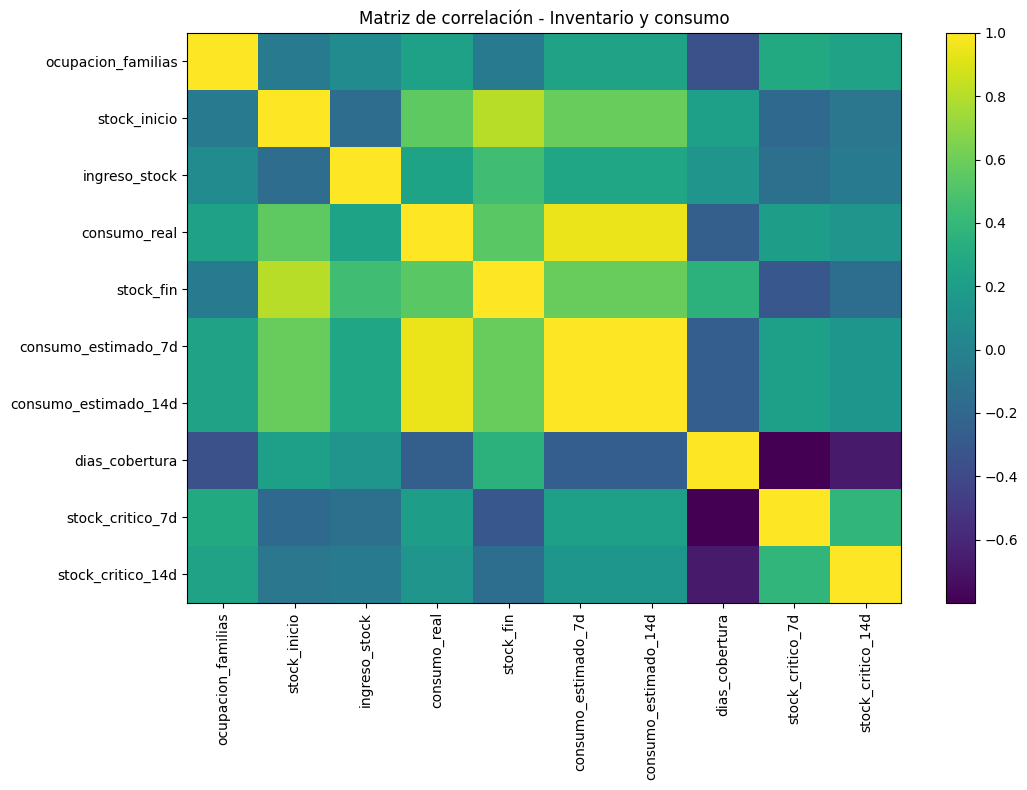

In [33]:
plt.figure(figsize=(11, 8))
plt.imshow(corr_consumo, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_consumo.columns)), corr_consumo.columns, rotation=90)
plt.yticks(range(len(corr_consumo.columns)), corr_consumo.columns)
plt.title("Matriz de correlación - Inventario y consumo")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matriz_correlacion_consumo.png", dpi=150)
plt.show()

## 10. EDA de donaciones

In [34]:
display(donaciones.describe(include="all").T)

donaciones.describe(include="all").T.to_csv(
    OUTPUT_DIR / "estadisticas_descriptivas_donaciones.csv",
    encoding="utf-8-sig"
)

donaciones_tipo = donaciones.groupby("tipo_donante").agg(
    cantidad_donaciones=("donacion_id", "count"),
    cantidad_total_donada=("cantidad_donada", "sum"),
    valor_total_soles=("valor_estimado_soles", "sum"),
    valor_promedio_soles=("valor_estimado_soles", "mean")
).reset_index().sort_values("valor_total_soles", ascending=False)

donaciones_tipo.to_csv(OUTPUT_DIR / "donaciones_por_tipo_donante.csv", index=False, encoding="utf-8-sig")
donaciones_tipo

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
donacion_id,1500,1500,DON01500,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha,1500,NaN,NaN,NaN,2025-10-07 17:40:48,2025-01-01 00:00:00,2025-05-23 00:00:00,2025-10-11 00:00:00,2026-02-22 06:00:00,2026-07-11 00:00:00,NaN
tipo_donante,1500,6,Persona natural,534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_id,1500,30,ITM007,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_item,1500,30,Conservas de atún,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categoria,1500,4,alimentos,601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unidad_medida,1500,9,unidad,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad_donada,"1,500.000",NaN,NaN,NaN,64.830,1.000,26.000,48.000,84.000,445.000,57.734
valor_estimado_soles,"1,500.000",NaN,NaN,NaN,632.257,5.580,198.030,431.470,844.942,"6,057.860",645.207
campania,1500,5,Regular,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,tipo_donante,cantidad_donaciones,cantidad_total_donada,valor_total_soles,valor_promedio_soles
1,Empresa,326,35985,"341,874.020","1,048.693"
4,Persona natural,534,20151,"201,233.200",376.841
3,ONG,193,16479,"162,351.940",841.202
2,Iglesia/Comunidad,214,13609,"135,128.340",631.441
0,Campaña digital,132,6016,"56,996.440",431.791
5,Universidad,101,5005,"50,801.720",502.987


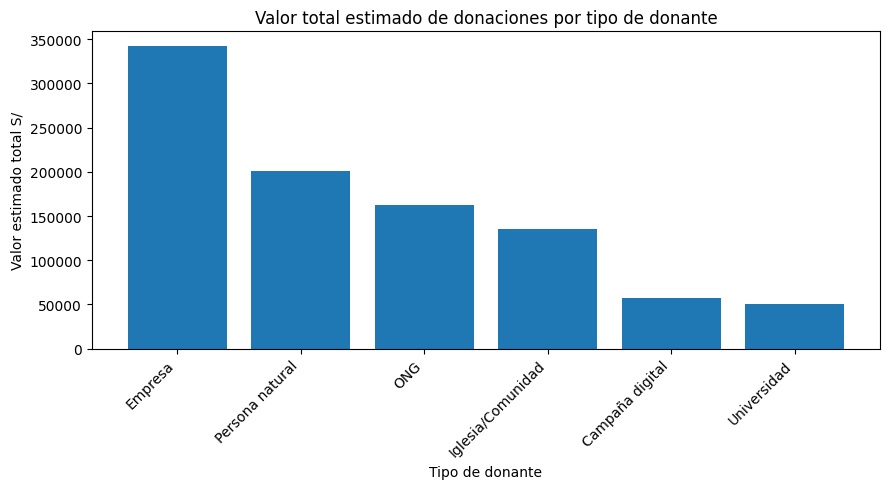

In [35]:
plt.figure(figsize=(9, 5))
plt.bar(donaciones_tipo["tipo_donante"], donaciones_tipo["valor_total_soles"])
plt.title("Valor total estimado de donaciones por tipo de donante")
plt.xlabel("Tipo de donante")
plt.ylabel("Valor estimado total S/")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "valor_donaciones_por_tipo_donante.png", dpi=150)
plt.show()

In [36]:
donaciones_categoria = donaciones.groupby("categoria").agg(
    cantidad_donaciones=("donacion_id", "count"),
    cantidad_total_donada=("cantidad_donada", "sum"),
    valor_total_soles=("valor_estimado_soles", "sum")
).reset_index().sort_values("valor_total_soles", ascending=False)

donaciones_categoria.to_csv(OUTPUT_DIR / "donaciones_por_categoria.csv", index=False, encoding="utf-8-sig")
donaciones_categoria

,categoria,cantidad_donaciones,cantidad_total_donada,valor_total_soles
0,alimentos,601,46126,"434,695.540"
2,insumos_medicos,510,26934,"262,278.020"
1,higiene,300,20045,"206,355.870"
3,medicamentos_soporte,89,4140,"45,056.230"


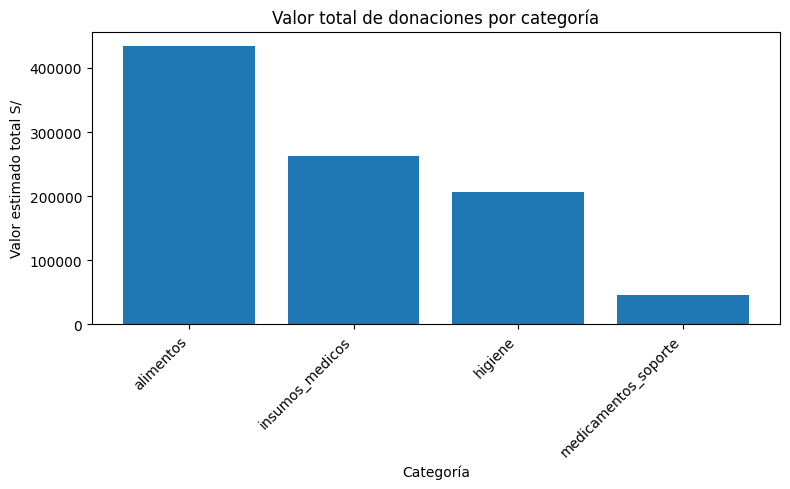

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(donaciones_categoria["categoria"], donaciones_categoria["valor_total_soles"])
plt.title("Valor total de donaciones por categoría")
plt.xlabel("Categoría")
plt.ylabel("Valor estimado total S/")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "valor_donaciones_por_categoria.png", dpi=150)
plt.show()